# Skin Cancer Detection - CNN Model




This notebook explores the task of skin cancer detection using deep learning. We will train and evaluate a CNN to classify skin lesions as either benign or malignant.

### Dataset
We will be using the skinskin_df_eda dataset, that is generated by the [Skin Cancer Detection - EDA.ipynb](https://https://colab.research.google.com/drive/165nG1oECZBc8RKacPjCbyKVZblZ1yM2-?usp=sharing) colab.

In [ ]:
# pip install keras

## Libraries

In [ ]:
import cv2
from collections import defaultdict
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(123)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from tqdm import tqdm
import itertools
import operator

import keras
from keras.utils import to_categorical
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPool2D, Dropout, Flatten,
    Dense, Concatenate, Activation
)
from tensorflow.keras.models import load_model
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

## Generic Methods Definition

In [ ]:
def show_images_per_class(
    skin_df,
    n_per_class=5,
    label_col="is_malignant",
    seed=42
):
    classes = sorted(skin_df[label_col].unique())
    n_classes = len(classes)

    fig, axes = plt.subplots(
        n_classes,
        n_per_class,
        figsize=(n_per_class * 3, n_classes * 3)
    )

    for row_idx, cls in enumerate(classes):
        class_df = skin_df[skin_df[label_col] == cls].sample(
            n=n_per_class,
            random_state=seed,
            replace=len(skin_df[skin_df[label_col] == cls]) < n_per_class
        )

        for col_idx, (_, row) in enumerate(class_df.iterrows()):
            img_path = get_image_path(row["image_id"])
            if img_path is None:
                axes[row_idx, col_idx].axis("off")
                continue

            img = Image.open(img_path).convert("RGB")
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis("off")

            # Título de la clase solo en la primera columna
            if col_idx == 0:
                axes[row_idx, col_idx].set_title(
                    cls,
                    fontsize=12,
                    loc="left",
                    pad=10
                )

    plt.tight_layout()
    plt.show()


In [ ]:
def show_image_with_prediction(
    skin_df,
    idx,             # índice de la imagen a mostrar
    x_val,           # imágenes normalizadas para el modelo
    X_tab_val,       # data tabular de validación
    y_val,           # labels de validación
    model,
    label_col="cell_type"
):
    # Imagen para la predicción
    img_norm = x_val[idx]
    tab_data = X_tab_val[idx]
    label_true = y_val[idx]

    # Predicción
    prediction = model.predict([img_norm[np.newaxis, ...], tab_data[np.newaxis, ...]])
    pred_prob = prediction[0,0]

    # Cargar imagen original del archivo
    img_path = skin_df.iloc[idx]['path']
    img_original = Image.open(img_path).convert("RGB")

    # Mostrar imagen
    plt.figure(figsize=(4,4))
    plt.imshow(img_original)
    plt.axis("off")

    # Título con label y probabilidad
    # true_label_name = skin_df[label_col].iloc[idx]
    if y_val[idx] == 0:
        true_label_name = "Benign"
    else:
        true_label_name = "Malignant"
    plt.title(f"True: {true_label_name}\nPred prob malignancy: {pred_prob:.2f}", fontsize=12)
    plt.show()

## Reading & Processing data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
BASE_PATH = "/kaggle/input/skin-cancer-mnist-ham10000"
IMG_DIRS = [
    "HAM10000_images_part_1",
    "HAM10000_images_part_2"
]

def get_image_path(image_id):
    for d in IMG_DIRS:
        path = os.path.join(BASE_PATH, d, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None


In [ ]:
skin_df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes

In [ ]:
drive_path = '/content/drive/MyDrive/skin_df_eda.xlsx'
skin_df = pd.read_excel(drive_path)

print("skin_df loaded successfully.\n")
display(skin_df.head())

# Ensure `is_malignant` is string type for ImageDataGenerator
skin_df['is_malignant_str'] = skin_df['is_malignant'].astype(str)

skin_df loaded successfully.



,lesion_id,image_id,dx_type,age,sex,localization,path,cell_type,cell_type_idx,is_malignant,image_hash
0,HAM_0000118,ISIC_0027419,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,34060fcaa8639d8bb0a4ed2039d53759
1,HAM_0000118,ISIC_0025030,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,e92f770c844315ac742ceefc3d9460dd
2,HAM_0002730,ISIC_0026769,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,968fb50ace9a1378e279b2e7b341f34f
3,HAM_0002730,ISIC_0025661,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,1e2f94fddad0005418e5fa7f35f65a46
4,HAM_0001466,ISIC_0031633,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,9dfd09a56cce8b3dda485fe8805031ea


In [ ]:
skin_df['path'] = skin_df['image_id'].apply(get_image_path)

In [ ]:
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9966 entries, 0 to 9965
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   lesion_id         9966 non-null   object 
 1   image_id          9966 non-null   object 
 2   dx_type           9966 non-null   object 
 3   age               9966 non-null   float64
 4   sex               9966 non-null   object 
 5   localization      9966 non-null   object 
 6   path              9966 non-null   object 
 7   cell_type         9966 non-null   object 
 8   cell_type_idx     9966 non-null   int64  
 9   is_malignant      9966 non-null   bool   
 10  image_hash        9966 non-null   object 
 11  is_malignant_str  9966 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 866.3+ KB


In [ ]:
skin_df.head()

,lesion_id,image_id,dx_type,age,sex,localization,path,cell_type,cell_type_idx,is_malignant,image_hash,is_malignant_str
0,HAM_0000118,ISIC_0027419,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,34060fcaa8639d8bb0a4ed2039d53759,False
1,HAM_0000118,ISIC_0025030,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,e92f770c844315ac742ceefc3d9460dd,False
2,HAM_0002730,ISIC_0026769,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,968fb50ace9a1378e279b2e7b341f34f,False
3,HAM_0002730,ISIC_0025661,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,1e2f94fddad0005418e5fa7f35f65a46,False
4,HAM_0001466,ISIC_0031633,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,9dfd09a56cce8b3dda485fe8805031ea,False


In [ ]:
skin_df[['sex', 'age', 'localization']]

,sex,age,localization
0,male,80.0,scalp
1,male,80.0,scalp
2,male,80.0,scalp
3,male,80.0,scalp
4,male,75.0,ear
...,...,...,...
9961,male,40.0,abdomen
9962,male,40.0,abdomen
9963,male,40.0,abdomen
9964,male,80.0,face


# Show sample images

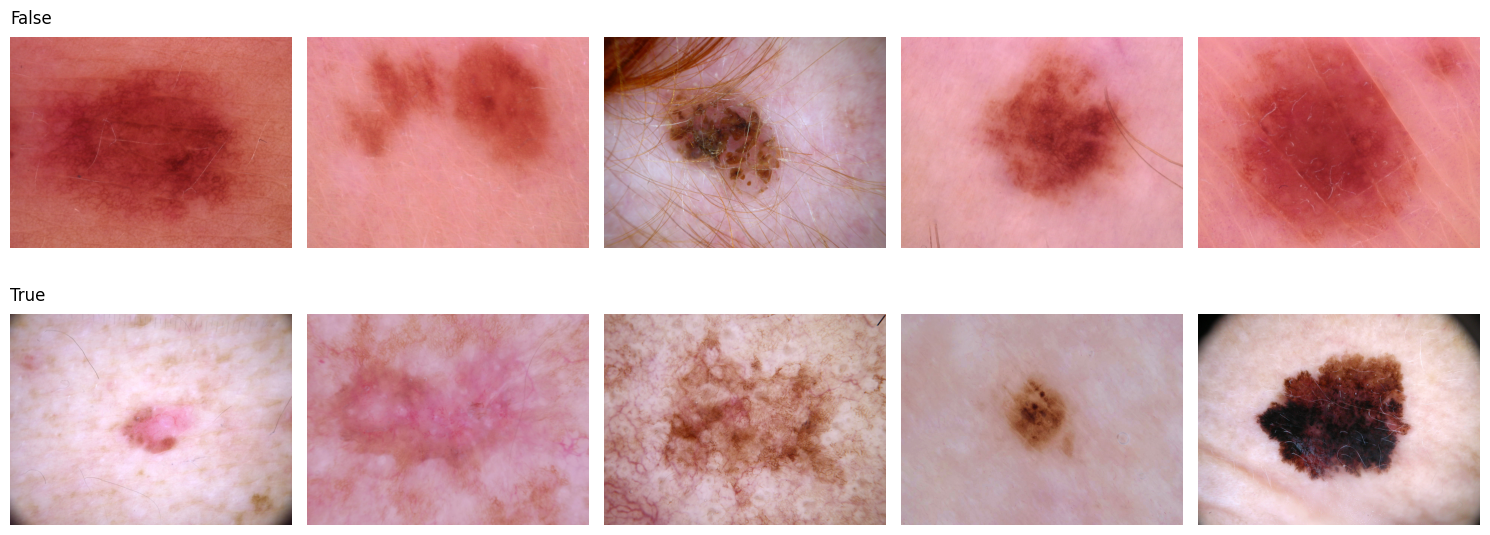

In [ ]:
show_images_per_class(skin_df, n_per_class=5)

In [ ]:
skin_df.columns

Index(['lesion_id', 'image_id', 'dx_type', 'age', 'sex', 'localization',
       'path', 'cell_type', 'cell_type_idx', 'is_malignant', 'image_hash',
       'is_malignant_str'],
      dtype='object')

In [ ]:
skin_df[['sex', 'age', 'localization']]

,sex,age,localization
0,male,80.0,scalp
1,male,80.0,scalp
2,male,80.0,scalp
3,male,80.0,scalp
4,male,75.0,ear
...,...,...,...
9961,male,40.0,abdomen
9962,male,40.0,abdomen
9963,male,40.0,abdomen
9964,male,80.0,face


# Preprocess the data

Images are loaded from disk, converted to RGB, resized to 100 × 75 pixels, and normalized to the
[0, 1]
[0,1] range; samples with missing or invalid images are removed.

Tabular features (age, sex, localization) are extracted; missing age values are imputed using the median, and categorical variables are one-hot encoded.

Image data, tabular data, and binary labels are assembled into aligned multimodal arrays.

The dataset is split into training, validation, and test sets using index-based stratified sampling to preserve class balance and multimodal alignment.

Image inputs are standardized using training-set statistics only, preventing data leakage.

Tabular features are standardized with a StandardScaler fitted on the training set and applied to validation and test sets.

In [ ]:
# ===============================
# Config
# ===============================
## original size 600 x 450
IMG_WIDTH = 100
IMG_HEIGHT = 75
RANDOM_STATE = 1234

# ===============================
# Image loading + resize
# ===============================
def load_and_resize_image(path):
    if pd.isna(path):
        return None
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        img = np.asarray(img, dtype=np.float32) / 255.0
        return img
    except:
        return None

skin_df['image'] = skin_df['path'].apply(load_and_resize_image)
skin_df.dropna(subset=['image'], inplace=True)
skin_df.reset_index(drop=True, inplace=True)

# ===============================
# Tabular features
# ===============================
tab_df = skin_df[['age', 'sex', 'localization']].copy()

# NOTE: imputación previa (aceptable para experimento)
tab_df['age'] = tab_df['age'].fillna(tab_df['age'].median())
tab_df = pd.get_dummies(tab_df, columns=['sex', 'localization'], drop_first=True)

# ===============================
# Final arrays
# ===============================
X_img = np.stack(skin_df['image'].values)
X_tab = tab_df.values
y = skin_df['is_malignant'].astype(int).values

# ===============================
# Index-based split (safe for multimodal)
# ===============================
indices = np.arange(len(skin_df))

# Train / Test
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Train / Validation
idx_train, idx_val = train_test_split(
    idx_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y[idx_train]
)

# ===============================
# Build datasets
# ===============================
X_img_train = X_img[idx_train]
X_img_val   = X_img[idx_val]
X_img_test  = X_img[idx_test]

X_tab_train = X_tab[idx_train]
X_tab_val   = X_tab[idx_val]
X_tab_test  = X_tab[idx_test]

y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

print("Images:", X_img_train.shape, X_img_val.shape, X_img_test.shape)
print("Tabular:", X_tab_train.shape, X_tab_val.shape, X_tab_test.shape)
print("Labels:", y_train.shape, y_val.shape, y_test.shape)

# ===============================
# Image normalization (NO leakage)
# ===============================
mean = X_img_train.mean()
std  = X_img_train.std()

x_train = (X_img_train - mean) / std
x_val   = (X_img_val   - mean) / std
x_test  = (X_img_test  - mean) / std

x_train = x_train.reshape(x_train.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)
x_val   = x_val.reshape(x_val.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)
x_test  = x_test.reshape(x_test.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)

# ===============================
# Tabular normalization (NO leakage)
# ===============================
scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_val   = scaler.transform(X_tab_val)
X_tab_test  = scaler.transform(X_tab_test)


Images: (7174, 75, 100, 3) (798, 75, 100, 3) (1994, 75, 100, 3)
Tabular: (7174, 15) (798, 15) (1994, 15)
Labels: (7174,) (798,) (1994,)


# Model training


The model has two convolutional blocks.
The first block uses 32 filters to learn low-level features such as edges and textures, while the second block increases to 64 filters to capture more complex patterns. Each convolution is followed by batch normalization and ReLU activation, then max pooling to reduce spatial size and dropout to prevent overfitting.

After feature extraction, the network flattens the feature maps and uses a dense layer with 128 neurons to learn high-level representations, again with batch normalization, ReLU, and dropout.

The final layer is a single sigmoid neuron, which outputs a probability for the positive class, making the model suitable for binary classification.



- 32 filters to capture simple, low-level features such as edges, color contrasts, and textures.
- the model increases the number of filters to 64 so it can learn more complex and abstract patterns (shapes, structures, lesion characteristics).

- Batch Normalization: normalizes activations to stabilize training, speed up convergence, and reduce overfitting.

- ReLU Activation: introduces non-linearity, allowing the network to learn complex patterns efficiently.

- Dense layer (128 neurons): combines extracted features into a high-level representation to support the final classification.

In [ ]:
IMG_HEIGHT = 75
IMG_WIDTH = 100
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 3e-4

In [ ]:
# ===============================
# Config
# ===============================

IMG_HEIGHT = 75
IMG_WIDTH = 100
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 3e-4


# ===============================
# Model architecture (FINAL)
# ===============================

model = Sequential([

    # ----- Block 1 -----
    Conv2D(32, (3,3), padding='same', input_shape=INPUT_SHAPE),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    # ----- Block 2 -----
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.4),

    # ----- Dense head -----
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 100, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 100, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 37, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,753,505 (14.32 MB)

 Trainable params: 3,752,865 (14.32 MB)

 Non-trainable params: 640 (2.50 KB)

The model is trained using the Adam optimizer with a fixed learning rate and binary cross-entropy loss, appropriate for binary classification. Performance is evaluated using AUC and recall, prioritizing sensitivity to malignant cases.
*   Binary cross-entropy: measures the difference between the true label (0 or 1) and the predicted probability
*   The Adam optimizer is an optimization algorithm that updates model weights using adaptive learning rates.


To handle class imbalance, class weights are applied, giving higher importance to the minority class.

Data augmentation (small rotations, zooms, and shifts) is applied to improve generalization and reduce overfitting.

Finnaly we add a callback, that is a mechanism that monitors training and automatically adjusts the process during learning.
* ReduceLROnPlateau lowers the learning rate when validation AUC stops improving, enabling finer optimization.
* EarlyStopping halts training when validation AUC no longer improves and restores the best model weights to prevent overfitting.

In [ ]:
# ===============================
# Compile
# ===============================

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


# ===============================
# Class weights
# ===============================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weight)

# ===============================
# Callbacks
# ===============================

lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ===============================
# Callbacks
# ===============================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ===============================
# Data augmentation
# ===============================

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_img_train)


# ===============================
# Train
# ===============================

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stop,
               lr_reduction
               ],
    verbose=1
)


Class weights: {0: np.float64(0.6219871683717704), 1: np.float64(2.549395877754087)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


224/224 ━━━━━━━━━━━━━━━━━━━━ 47s 148ms/step - auc: 0.7154 - loss: 0.6871 - recall: 0.7547 - val_auc: 0.8029 - val_loss: 0.6063 - val_recall: 0.9679 - learning_rate: 3.0000e-04
Epoch 2/50
  1/224 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - auc: 0.7630 - loss: 0.5266 - recall: 1.0000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7630 - loss: 0.5266 - recall: 1.0000 - val_auc: 0.8014 - val_loss: 0.6073 - val_recall: 0.9679 - learning_rate: 3.0000e-04
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - auc: 0.8201 - loss: 0.5077 - recall: 0.8314 - val_auc: 0.8220 - val_loss: 0.3914 - val_recall: 0.4423 - learning_rate: 3.0000e-04
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7686 - loss: 0.5085 - recall: 1.0000 - val_auc: 0.8224 - val_loss: 0.3930 - val_recall: 0.4872 - learning_rate: 3.0000e-04
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - auc: 0.8104 - loss: 0.5056 - recall: 0.8049 - val_auc: 0.8318 - val_loss: 0.5359 - val_recall: 0.8333 - learning_rate: 3.0000e-04
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7299 - loss: 0.5717 - recall: 0.6667 - val_auc: 0.8318 - val_loss: 0.5325 - val_recall: 0.8333 - learning_rate: 3.0000e-04
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - auc: 0.8420 - loss: 0.4798 - re

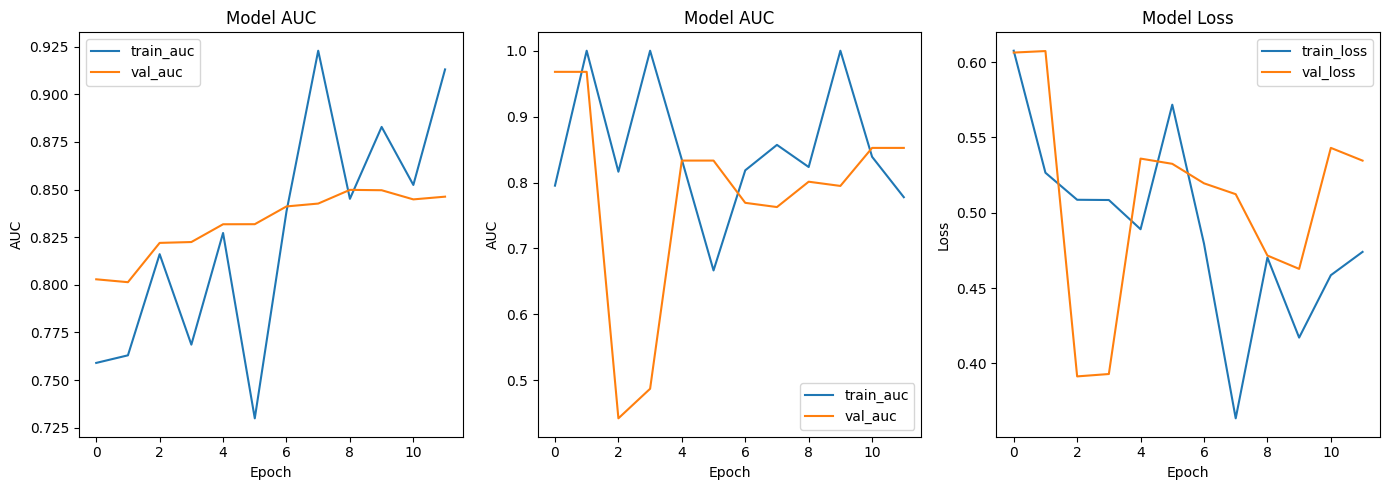

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# AUC
axs[0].plot(history.history['auc'], label='train_auc')
axs[0].plot(history.history['val_auc'], label='val_auc')
axs[0].set_title('Model AUC')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('AUC')
axs[0].legend()

# Recall
axs[1].plot(history.history['recall'], label='train_auc')
axs[1].plot(history.history['val_recall'], label='val_auc')
axs[1].set_title('Model AUC')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('AUC')
axs[1].legend()

# Loss
axs[2].plot(history.history['loss'], label='train_loss')
axs[2].plot(history.history['val_loss'], label='val_loss')
axs[2].set_title('Model Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()

plt.tight_layout()
plt.show()


# Evaluate model

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc: 0.8493 - loss: 0.4567 - recall: 0.7812
Test Loss      : 0.4492
Test AUC       : 0.8582
Test Recall       : 0.8107
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Probabilities summary: min = 1.0820068e-07 mean = 0.35587946 max = 0.9790749
ROC AUC (sklearn): 0.8583


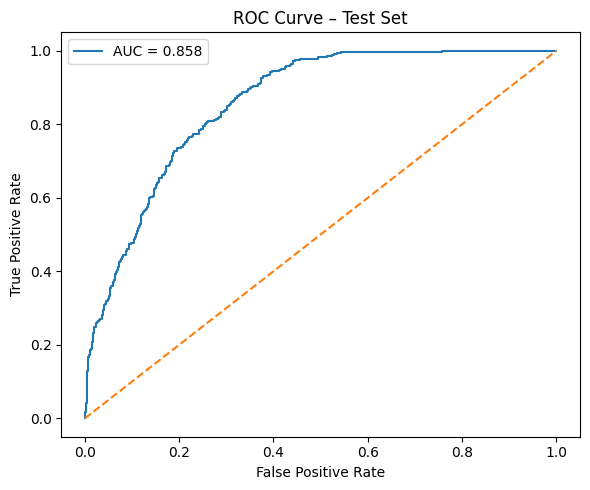

In [ ]:
# ===============================
# Evaluate model
# ===============================
loss_test, auc_test, recall_test = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"Test Loss      : {loss_test:.4f}")
print(f"Test AUC       : {auc_test:.4f}")
print(f"Test Recall       : {recall_test:.4f}")

# ===============================
# Predict probabilities
# ===============================
y_test_prob = model.predict(x_test).ravel()

print(
    "Probabilities summary:",
    "min =", np.min(y_test_prob),
    "mean =", np.mean(y_test_prob),
    "max =", np.max(y_test_prob)
)

# ===============================
# ROC AUC
# ===============================
auc_sklearn = roc_auc_score(y_test, y_test_prob)
print(f"ROC AUC (sklearn): {auc_sklearn:.4f}")

# ===============================
# ROC Curve
# ===============================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_sklearn:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Test Set')
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(['#da6b87',
                              '#7d233c', #rosa oscuro
                              '#cfbdb0', #beige oscuro
                              '#f1e6de'
                              ])

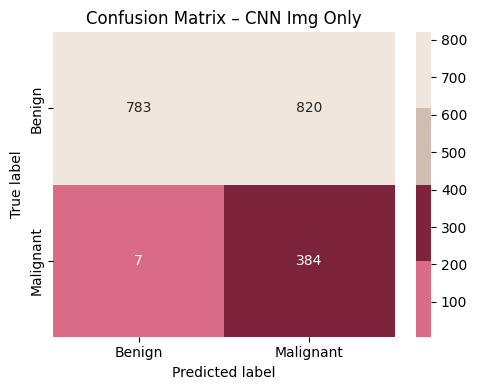

In [ ]:
# ===============================
# Binary predictions (threshold)
# ===============================
threshold = 0.15
y_test_pred = (y_test_prob >= threshold).astype(int)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_test_pred)


plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=custom_cmap,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – CNN Img Only')
plt.tight_layout()
plt.show()



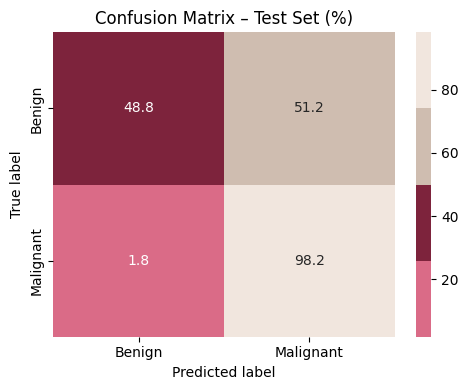

In [ ]:
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100



plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap=custom_cmap,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Test Set (%)')
plt.tight_layout()
plt.show()


# Save model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/models/"
MODEL_NAME = "melanoma_model_img.h5"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save(MODEL_PATH + MODEL_NAME)
print(f"Model saved at: {MODEL_PATH + MODEL_NAME}")

Model saved at: /content/drive/MyDrive/models/melanoma_model_img.h5


# Visualize random prediction examples

In [ ]:
model = load_model(MODEL_PATH + MODEL_NAME)

414


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 75, 100, 3))', 'Tensor(shape=(1, 15))')
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step


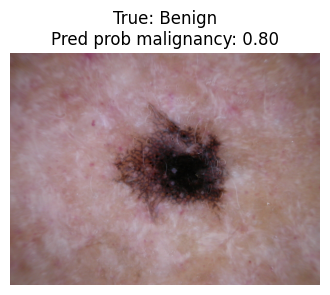

In [ ]:
# Elegís el índice que quieras, por ejemplo:
idx = random.randint(0, x_val.shape[0] - 1)
print(idx) # 152
idx = 152
show_image_with_prediction(
    skin_df=skin_df,
    idx=idx,
    x_val=x_val,
    X_tab_val=X_tab_val,
    y_val=y_val,
    model=model,
    label_col="cell_type"  # o "is_malignant" según tu dataframe
)

